
# Diagnóstico e cálculo de dimensão fractal de imagem preto/branco

Este notebook JupyterLab verifica se o kernel possui as ferramentas mínimas para estimar a **dimensão fractal** de uma figura binária — isto é, uma imagem em preto e branco — usando o método de **contagem de caixas** (*box-counting*).

## Objetivos didáticos

1. Verificar se o ambiente Python do JupyterLab possui as bibliotecas necessárias.
2. Gerar uma imagem fractal sintética de teste, o **tapete de Sierpinski**.
3. Estimar sua dimensão fractal e comparar com o valor teórico aproximado.
4. Permitir que o aluno analise uma imagem preto/branco própria.
5. Salvar resultados em CSV, PNG e TXT.

## Observação importante

O método usado aqui estima a dimensão fractal pela relação:

\[
N(\epsilon) \sim \epsilon^{-D}
\]

onde:

- \(N(\epsilon)\) é o número de caixas ocupadas;
- \(\epsilon\) é o tamanho da caixa;
- \(D\) é a dimensão fractal estimada.

No gráfico log-log, a dimensão é estimada pela inclinação da reta ajustada a:

\[
\log N(\epsilon) \times \log(1/\epsilon)
\]

Para figuras comuns preenchidas, a dimensão estimada pode ficar próxima de 2. Para linhas, bordas e padrões ramificados, a dimensão tende a ficar entre 1 e 2.



## Célula 1 — Verificação do ambiente

Esta célula verifica bibliotecas importantes para o notebook.

Bibliotecas essenciais:

- `numpy`: operações numéricas e matrizes;
- `matplotlib`: leitura simples de imagens, gráficos e salvamento de figuras;
- `pandas`: tabela de resultados e exportação CSV.

Bibliotecas opcionais:

- `PIL`/`Pillow`: leitura mais robusta de imagens;
- `ipywidgets`: painel simples para escolher arquivo e parâmetros;
- `scikit-image`: não é necessária nesta versão, mas pode ser útil em versões futuras.


In [ ]:

# ============================================================
# CÉLULA 1 — Diagnóstico de pacotes do kernel
# ============================================================

import sys
import importlib
import platform
from datetime import datetime
from pathlib import Path

print("Diagnóstico iniciado em:", datetime.now().isoformat(timespec="seconds"))
print("Python:", sys.version)
print("Executável:", sys.executable)
print("Plataforma:", platform.platform())
print()

PACOTES = [
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("matplotlib", "matplotlib"),
    ("PIL / Pillow", "PIL"),
    ("ipywidgets", "ipywidgets"),
    ("jupyterlab_widgets", "jupyterlab_widgets"),
    ("scipy", "scipy"),
    ("scikit-image", "skimage"),
]

resultado_pacotes = []
for nome, modulo in PACOTES:
    try:
        m = importlib.import_module(modulo)
        versao = getattr(m, "__version__", "versão não informada")
        status = "OK"
    except Exception as e:
        versao = f"indisponível: {type(e).__name__}: {e}"
        status = "AUSENTE"
    resultado_pacotes.append((nome, modulo, status, versao))

for nome, modulo, status, versao in resultado_pacotes:
    print(f"{nome:18s} módulo={modulo:18s} status={status:8s} versão={versao}")

print()
print("Conclusão preliminar:")
essenciais_ok = all(r[2] == "OK" for r in resultado_pacotes[:3])
if essenciais_ok:
    print("✅ O kernel possui as bibliotecas essenciais para este notebook.")
else:
    print("⚠️ Alguma biblioteca essencial está ausente. Verifique numpy, pandas e matplotlib.")


Diagnóstico iniciado em: 2026-06-03T13:56:24
Python: 3.11.6 | packaged by conda-forge | (main, Oct  3 2023, 10:40:35) [GCC 12.3.0]
Executável: /opt/conda/bin/python
Plataforma: Linux-6.17.0-29-generic-x86_64-with-glibc2.35



numpy              módulo=numpy              status=OK       versão=2.4.4
pandas             módulo=pandas             status=OK       versão=2.3.3
matplotlib         módulo=matplotlib         status=OK       versão=3.10.9
PIL / Pillow       módulo=PIL                status=OK       versão=12.2.0
ipywidgets         módulo=ipywidgets         status=OK       versão=8.1.8
jupyterlab_widgets módulo=jupyterlab_widgets status=OK       versão=3.0.16
scipy              módulo=scipy              status=OK       versão=1.17.1
scikit-image       módulo=skimage            status=AUSENTE  versão=indisponível: ModuleNotFoundError: No module named 'skimage'

Conclusão preliminar:
✅ O kernel possui as bibliotecas essenciais para este notebook.



## Célula 2 — Importações e configuração gráfica persistente

Esta célula usa `%matplotlib inline` e define a forma de mostrar figuras no JupyterLab:

1. a função cria uma figura `matplotlib`;
2. a figura é exibida com `display(fig)`, sem `plt.show()`;
3. a figura é salva em PNG;
4. a figura é fechada com `plt.close(fig)` para evitar duplicações;
5. depois disso, o notebook mostra uma mensagem e, quando útil, a imagem salva.


In [ ]:

# ============================================================
# CÉLULA 2 — Importações e configuração
# ============================================================

%matplotlib inline

import math
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from pathlib import Path
from IPython.display import display, Markdown, Image as IPyImage

try:
    from PIL import Image
    PIL_DISPONIVEL = True
except Exception:
    Image = None
    PIL_DISPONIVEL = False

PASTA_SAIDA = Path("resultados_dimensao_fractal")
PASTA_SAIDA.mkdir(exist_ok=True)

print("Pasta de saída:", PASTA_SAIDA.resolve())
print("PIL/Pillow disponível:", PIL_DISPONIVEL)


Pasta de saída: /home/jovyan/ambiente_laboratorio/fractais/resultados_dimensao_fractal
PIL/Pillow disponível: True



## Célula 3 — Funções para imagem binária e dimensão fractal

O bloco abaixo define as funções principais.

A ideia central é transformar a imagem em uma matriz booleana:

- `True`: pixels pertencentes ao objeto analisado;
- `False`: fundo.

Depois, a matriz é coberta com caixas de vários tamanhos. Para cada tamanho, contamos quantas caixas contêm pelo menos um pixel do objeto. A inclinação do gráfico log-log fornece a estimativa da dimensão fractal.


In [ ]:

# ============================================================
# CÉLULA 3 — Funções de processamento e box-counting
# ============================================================

def gerar_sierpinski(nivel=5):
    """Gera uma imagem binária do tapete de Sierpinski.

    Retorna uma matriz booleana em que True representa a parte ocupada.
    O tamanho da matriz é 3**nivel por 3**nivel.
    """
    if nivel < 1:
        raise ValueError("nivel deve ser >= 1")

    tamanho = 3 ** nivel
    img = np.ones((tamanho, tamanho), dtype=bool)

    def remover_centro(x0, y0, tam):
        if tam < 3:
            return
        t = tam // 3
        img[y0 + t:y0 + 2*t, x0 + t:x0 + 2*t] = False
        for dy in range(3):
            for dx in range(3):
                if dx == 1 and dy == 1:
                    continue
                remover_centro(x0 + dx*t, y0 + dy*t, t)

    remover_centro(0, 0, tamanho)
    return img


def imagem_para_cinza(array):
    """Converte imagem RGB/RGBA/cinza para escala de cinza normalizada entre 0 e 1."""
    arr = np.asarray(array)
    if arr.dtype.kind in "ui":
        arr = arr.astype(float) / np.iinfo(array.dtype).max
    else:
        arr = arr.astype(float)
        if arr.max() > 1.0:
            arr = arr / 255.0

    if arr.ndim == 2:
        gray = arr
    elif arr.ndim == 3:
        rgb = arr[..., :3]
        gray = 0.299 * rgb[..., 0] + 0.587 * rgb[..., 1] + 0.114 * rgb[..., 2]
    else:
        raise ValueError("Formato de imagem não suportado.")
    return gray


def carregar_imagem_binaria(caminho, limiar=0.5, objeto="preto"):
    """Lê uma imagem e converte para matriz booleana.

    Parâmetros:
    - caminho: caminho do arquivo de imagem;
    - limiar: valor entre 0 e 1 para separar preto/branco;
    - objeto: 'preto' ou 'branco', indicando qual cor será tratada como objeto.
    """
    caminho = Path(caminho)
    if not caminho.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {caminho}")

    if PIL_DISPONIVEL:
        img = Image.open(caminho).convert("RGBA")
        arr = np.array(img)
    else:
        arr = mpimg.imread(caminho)

    gray = imagem_para_cinza(arr)
    objeto = objeto.lower().strip()
    if objeto == "preto":
        binary = gray < limiar
    elif objeto == "branco":
        binary = gray >= limiar
    else:
        raise ValueError("objeto deve ser 'preto' ou 'branco'")

    return binary, gray


def extrair_contorno(binary):
    """Extrai uma aproximação simples do contorno de uma figura binária.

    Esta função é opcional. Ela é útil quando se deseja estimar a dimensão da borda
    e não da área preenchida da figura.
    """
    Z = np.asarray(binary, dtype=bool)
    padded = np.pad(Z, 1, mode="constant", constant_values=False)
    centro = padded[1:-1, 1:-1]
    vizinhos_4 = (
        padded[:-2, 1:-1] &
        padded[2:, 1:-1] &
        padded[1:-1, :-2] &
        padded[1:-1, 2:]
    )
    return centro & (~vizinhos_4)


def contar_caixas_ocupadas(binary, k):
    """Conta quantas caixas k x k contêm pelo menos um pixel ocupado."""
    Z = np.asarray(binary, dtype=bool)
    h, w = Z.shape
    pad_h = (-h) % k
    pad_w = (-w) % k
    Zp = np.pad(Z, ((0, pad_h), (0, pad_w)), mode="constant", constant_values=False)
    hp, wp = Zp.shape
    blocos = Zp.reshape(hp // k, k, wp // k, k)
    ocupadas = blocos.any(axis=(1, 3))
    return int(np.count_nonzero(ocupadas))


def tamanhos_de_caixa(shape, minimo=2):
    """Escolhe tamanhos de caixas em potências de 2 compatíveis com a imagem."""
    menor_dim = min(shape)
    max_k = menor_dim // 2
    if max_k < minimo:
        raise ValueError("Imagem pequena demais para box-counting.")

    tamanhos = []
    k = 1
    while k <= max_k:
        if k >= minimo:
            tamanhos.append(k)
        k *= 2
    tamanhos = sorted(tamanhos, reverse=True)
    return np.array(tamanhos, dtype=int)


def estimar_dimensao_fractal(binary, usar_contorno=False, tamanhos=None):
    """Estima a dimensão fractal por box-counting.

    Retorna:
    - dimensao estimada;
    - dataframe com tamanhos de caixa, contagens e coordenadas log-log;
    - matriz binária efetivamente analisada.
    """
    Z = np.asarray(binary, dtype=bool)
    if usar_contorno:
        Z = extrair_contorno(Z)

    if np.count_nonzero(Z) == 0:
        raise ValueError("A imagem binária não contém pixels do objeto analisado.")

    if tamanhos is None:
        tamanhos = tamanhos_de_caixa(Z.shape)

    registros = []
    escala_ref = max(Z.shape)
    for k in tamanhos:
        N = contar_caixas_ocupadas(Z, int(k))
        if N > 0:
            registros.append({
                "tamanho_caixa_pixels": int(k),
                "N_caixas_ocupadas": int(N),
                "log_1_sobre_epsilon": float(np.log(escala_ref / k)),
                "log_N": float(np.log(N)),
            })

    df = pd.DataFrame(registros)
    if len(df) < 2:
        raise ValueError("Pontos insuficientes para ajustar a reta log-log.")

    x = df["log_1_sobre_epsilon"].to_numpy()
    y = df["log_N"].to_numpy()
    coef = np.polyfit(x, y, 1)
    dimensao = float(coef[0])
    intercepto = float(coef[1])
    df["log_N_ajustado"] = dimensao * x + intercepto

    return dimensao, df, Z

print("Funções carregadas.")


Funções carregadas.



## Célula 4 — Função de gráfico persistente

A função `gerar_grafico_box_counting()` retorna uma figura `matplotlib`.

Na célula seguinte, a figura será exibida com `display(fig)`, salva em PNG e fechada com `plt.close(fig)`, sem usar `plt.show()`.


In [ ]:

# ============================================================
# CÉLULA 4 — Geração de gráfico persistente
# ============================================================

def gerar_grafico_box_counting(binary_analisada, df, dimensao, titulo="Box-counting"):
    """Cria e retorna uma figura matplotlib com imagem binária e ajuste log-log."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(binary_analisada, cmap="gray_r", interpolation="nearest")
    axes[0].set_title("Imagem binária analisada")
    axes[0].set_axis_off()

    axes[1].plot(
        df["log_1_sobre_epsilon"],
        df["log_N"],
        marker="o",
        linestyle="None",
        label="dados"
    )
    axes[1].plot(
        df["log_1_sobre_epsilon"],
        df["log_N_ajustado"],
        linestyle="-",
        label=f"ajuste: D = {dimensao:.4f}"
    )
    axes[1].set_xlabel("log(1/epsilon)")
    axes[1].set_ylabel("log(N)")
    axes[1].set_title("Ajuste log-log")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    fig.suptitle(titulo)
    fig.tight_layout()
    return fig

print("Função gerar_grafico_box_counting() carregada.")


Função gerar_grafico_box_counting() carregada.


## Método de box-counting

A figura abaixo resume o método usado neste notebook para estimar a dimensão fractal de uma imagem preto/branco.

<img src="imagens/dim_fractal.png" width="850">

No método de box-counting, cobrimos a imagem com caixas de diferentes tamanhos e contamos quantas caixas contêm parte da estrutura analisada.  
A dimensão fractal é estimada a partir da relação entre o tamanho das caixas e o número de caixas ocupadas.


## Célula 5 — Teste com tapete de Sierpinski

Esta célula testa o algoritmo com uma figura fractal conhecida.

A dimensão teórica do tapete de Sierpinski é:

\[
D = \frac{\log 8}{\log 3} \approx 1,8928
\]

O valor estimado pode não ser exatamente igual por causa do tamanho finito da imagem e das escolhas de escala de caixa.


Dimensão estimada: 1.8790
Dimensão teórica aproximada do tapete de Sierpinski: 1.8928


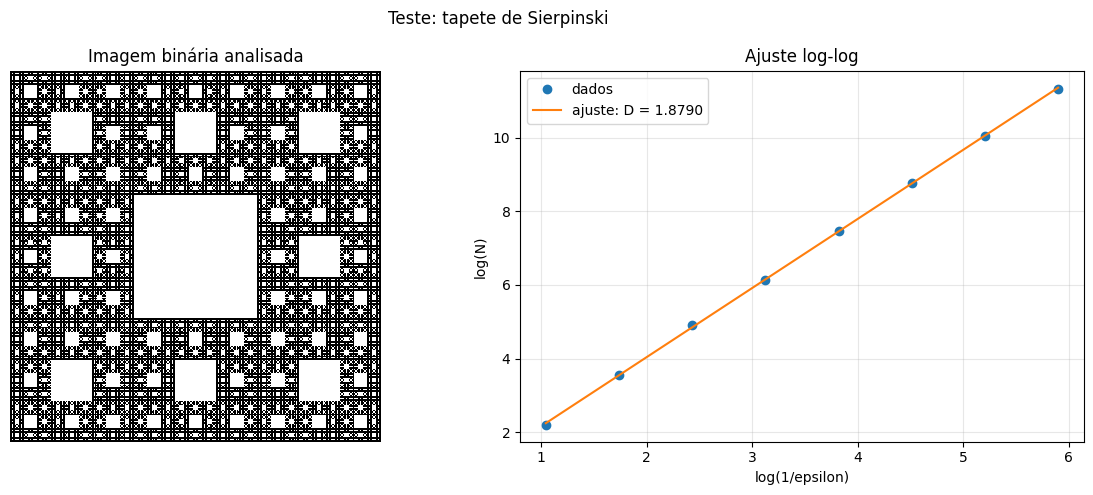


✅ **Teste concluído.**

- Dimensão estimada: **1.8790**
- Valor teórico aproximado: **1.8928**
- Figura salva em: `resultados_dimensao_fractal/teste_sierpinski_box_counting.png`
- Dados salvos em: `resultados_dimensao_fractal/teste_sierpinski_box_counting.csv`


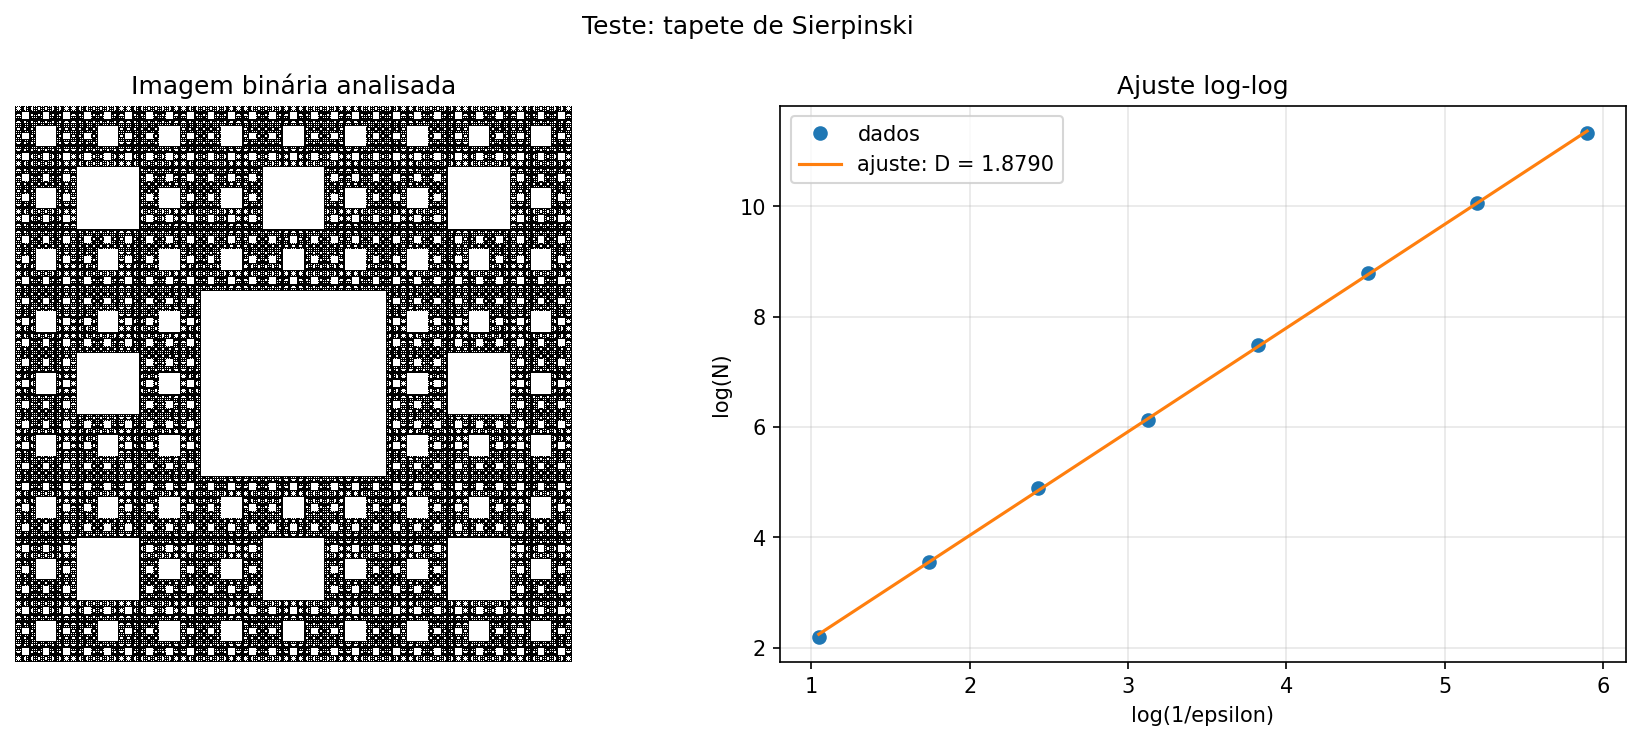

In [ ]:

# ============================================================
# CÉLULA 5 — Teste com tapete de Sierpinski
# ============================================================

binary_teste = gerar_sierpinski(nivel=6)
dimensao, df_box, Z_analisada = estimar_dimensao_fractal(binary_teste, usar_contorno=False)

valor_teorico = math.log(8) / math.log(3)
print(f"Dimensão estimada: {dimensao:.4f}")
print(f"Dimensão teórica aproximada do tapete de Sierpinski: {valor_teorico:.4f}")

fig = gerar_grafico_box_counting(
    Z_analisada,
    df_box,
    dimensao,
    titulo="Teste: tapete de Sierpinski"
)

arquivo_png = PASTA_SAIDA / "teste_sierpinski_box_counting.png"
arquivo_csv = PASTA_SAIDA / "teste_sierpinski_box_counting.csv"

fig.savefig(arquivo_png, dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)

df_box.to_csv(arquivo_csv, index=False)

display(Markdown(f"""
✅ **Teste concluído.**

- Dimensão estimada: **{dimensao:.4f}**
- Valor teórico aproximado: **{valor_teorico:.4f}**
- Figura salva em: `{arquivo_png}`
- Dados salvos em: `{arquivo_csv}`
"""))

display(IPyImage(filename=str(arquivo_png)))



## Célula 6 — Analisar uma imagem preto/branco do aluno

Para usar esta célula:

1. faça upload de uma imagem para a pasta do notebook;
2. altere a variável `CAMINHO_IMAGEM` para o nome do arquivo;
3. ajuste `LIMIAR`, se necessário;
4. escolha se o objeto analisado é `"preto"` ou `"branco"`;
5. escolha se deseja analisar a figura preenchida ou apenas o contorno.

Exemplos:

```python
CAMINHO_IMAGEM = "minha_figura.png"
OBJETO = "preto"
USAR_CONTORNO = False
```


In [ ]:

# ============================================================
# CÉLULA 6 — Análise de imagem fornecida pelo aluno
# ============================================================

# Edite estes parâmetros antes de rodar a célula.
CAMINHO_IMAGEM = "minha_figura_preto_branco.png"  # substitua pelo nome do arquivo
LIMIAR = 0.5                                      # entre 0 e 1
OBJETO = "preto"                                 # "preto" ou "branco"
USAR_CONTORNO = False                             # True para analisar só a borda

caminho = Path(CAMINHO_IMAGEM)

if not caminho.exists():
    display(Markdown(f"""
⚠️ **Arquivo não encontrado:** `{CAMINHO_IMAGEM}`

Faça upload da imagem para a mesma pasta do notebook ou altere `CAMINHO_IMAGEM`.
A célula de teste com Sierpinski já permite verificar que o algoritmo está funcionando.
"""))
else:
    binary_img, gray_img = carregar_imagem_binaria(caminho, limiar=LIMIAR, objeto=OBJETO)
    dimensao_img, df_img, Z_img = estimar_dimensao_fractal(binary_img, usar_contorno=USAR_CONTORNO)

    nome_base = caminho.stem
    sufixo = "contorno" if USAR_CONTORNO else "figura"
    arquivo_png = PASTA_SAIDA / f"{nome_base}_box_counting_{sufixo}.png"
    arquivo_csv = PASTA_SAIDA / f"{nome_base}_box_counting_{sufixo}.csv"
    arquivo_txt = PASTA_SAIDA / f"{nome_base}_relatorio_{sufixo}.txt"

    fig = gerar_grafico_box_counting(
        Z_img,
        df_img,
        dimensao_img,
        titulo=f"{caminho.name} — dimensão estimada = {dimensao_img:.4f}"
    )

    fig.savefig(arquivo_png, dpi=150, bbox_inches="tight")
    display(fig)
    plt.close(fig)

    df_img.to_csv(arquivo_csv, index=False)

    relatorio = {
        "arquivo": str(caminho),
        "limiar": LIMIAR,
        "objeto": OBJETO,
        "usar_contorno": USAR_CONTORNO,
        "dimensao_fractal_estimada": dimensao_img,
        "n_pixels_objeto": int(np.count_nonzero(Z_img)),
        "shape": list(Z_img.shape),
        "csv": str(arquivo_csv),
        "png": str(arquivo_png),
    }
    arquivo_txt.write_text(json.dumps(relatorio, indent=2, ensure_ascii=False), encoding="utf-8")

    modo = "contorno" if USAR_CONTORNO else "figura preenchida"
    display(Markdown(f"""
✅ **Análise concluída.**

- Arquivo analisado: `{caminho}`
- Dimensão fractal estimada: **{dimensao_img:.4f}**
- Modo de análise: **{modo}**
- PNG salvo em: `{arquivo_png}`
- CSV salvo em: `{arquivo_csv}`
- Relatório salvo em: `{arquivo_txt}`
"""))

    display(IPyImage(filename=str(arquivo_png)))



⚠️ **Arquivo não encontrado:** `minha_figura_preto_branco.png`

Faça upload da imagem para a mesma pasta do notebook ou altere `CAMINHO_IMAGEM`.
A célula de teste com Sierpinski já permite verificar que o algoritmo está funcionando.



## Célula 7 — Painel opcional com widgets

Esta célula cria um painel simples para o aluno informar caminho, limiar, cor do objeto e modo de análise.

Como já observamos em outros notebooks do SimServ, widgets podem exigir que a célula seja rodada duas vezes em algumas sessões do JupyterLab. Por isso, o modo principal acima, sem painel, é mantido como a forma mais robusta de uso.


In [ ]:

# ============================================================
# CÉLULA 7 — Painel opcional com ipywidgets
# ============================================================

try:
    import ipywidgets as widgets
    from IPython.display import clear_output
    WIDGETS_OK = True
except Exception as e:
    WIDGETS_OK = False
    print("ipywidgets indisponível:", e)

if WIDGETS_OK:
    caminho_w = widgets.Text(
        value="minha_figura_preto_branco.png",
        description="Imagem:",
        layout=widgets.Layout(width="500px")
    )
    limiar_w = widgets.FloatSlider(
        value=0.5,
        min=0.0,
        max=1.0,
        step=0.01,
        description="Limiar",
        readout_format=".2f",
        layout=widgets.Layout(width="500px")
    )
    objeto_w = widgets.Dropdown(
        options=["preto", "branco"],
        value="preto",
        description="Objeto:"
    )
    contorno_w = widgets.Checkbox(
        value=False,
        description="Analisar apenas contorno"
    )
    botao = widgets.Button(description="Analisar imagem", button_style="primary")
    saida = widgets.Output()

    def ao_clicar(_):
        with saida:
            clear_output(wait=True)
            caminho = Path(caminho_w.value)
            if not caminho.exists():
                display(Markdown(f"⚠️ Arquivo não encontrado: `{caminho}`"))
                return
            try:
                binary_img, _ = carregar_imagem_binaria(
                    caminho,
                    limiar=limiar_w.value,
                    objeto=objeto_w.value
                )
                dimensao_img, df_img, Z_img = estimar_dimensao_fractal(
                    binary_img,
                    usar_contorno=contorno_w.value
                )
                sufixo = "contorno" if contorno_w.value else "figura"
                arquivo_png = PASTA_SAIDA / f"{caminho.stem}_widget_{sufixo}.png"
                fig = gerar_grafico_box_counting(
                    Z_img,
                    df_img,
                    dimensao_img,
                    titulo=f"{caminho.name} — D = {dimensao_img:.4f}"
                )
                fig.savefig(arquivo_png, dpi=150, bbox_inches="tight")
                display(fig)
                plt.close(fig)
                display(Markdown(f"✅ Dimensão estimada: **{dimensao_img:.4f}**  \nPNG: `{arquivo_png}`"))
            except Exception as e:
                display(Markdown(f"❌ Erro na análise: `{type(e).__name__}: {e}`"))

    botao.on_click(ao_clicar)
    display(widgets.VBox([caminho_w, limiar_w, objeto_w, contorno_w, botao, saida]))
else:
    print("Painel opcional não disponível porque ipywidgets não foi importado.")



## Célula 8 — Interpretação dos resultados

Alguns cuidados importantes:

1. **Imagem preenchida:** se a figura for uma região compacta preenchida, a dimensão pode tender a 2.
2. **Linha ou contorno:** se a figura for uma linha, a dimensão pode tender a 1.
3. **Fractal real ou aproximado:** imagens digitais têm resolução finita; a estimativa depende das escalas disponíveis.
4. **Limiar:** pequenas mudanças no limiar podem alterar o conjunto de pixels analisado.
5. **Ruído:** ruídos, compressão JPEG e bordas borradas podem afetar a estimativa.

Para uso didático, recomenda-se começar com imagens PNG simples, preto/branco, sem compressão com perdas.
